<a href="https://colab.research.google.com/github/hoangchaugiahan/FUZZYLOGIC/blob/main/Vietnamesedishes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,Dropout

In [ ]:
datagen = ImageDataGenerator(rescale=1.0/255)
generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/food',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/food',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=10000,
    shuffle=False
)

class_labels = ['banh mi', 'banh trang', 'bun dau', 'goi cuon', 'pho']
X_batch, y_batch = next(generator)
X_batch_flat = X_batch.reshape(X_batch.shape[0], -1)
print("Input shape for ANN:", X_batch_flat.shape)
print("Label shape (one-hot):", y_batch.shape)

Found 27 images belonging to 5 classes.
Found 27 images belonging to 5 classes.
Input shape for ANN: (27, 3072)
Label shape (one-hot): (27, 5)


In [ ]:
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/food',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=10000,
    shuffle=False
)
x_train, y_train = next(generator)
x_test, y_test = next(test_generator)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

Found 27 images belonging to 5 classes.
(27, 3072) (27, 5)
(27, 3072) (27, 5)


In [ ]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(32*32*3,)),
    Dense(128, activation='relu'),
    Dense(generator.num_classes, activation='softmax')

])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=500, batch_size=100, validation_data=(x_test, y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2222 - loss: 1.7317 - val_accuracy: 0.1852 - val_loss: 2.4407
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step - accuracy: 0.1852 - loss: 2.4407 - val_accuracy: 0.2222 - val_loss: 1.6089
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2222 - loss: 1.6089 - val_accuracy: 0.2593 - val_loss: 1.6116
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.2593 - loss: 1.6116 - val_accuracy: 0.4444 - val_loss: 1.5265
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.4444 - loss: 1.5265 - val_accuracy: 0.5185 - val_loss: 1.2383
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5185 - loss: 1.2383 - val_accuracy: 0.5185 - val_loss: 1.1671
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5185 - loss: 1.1671 - val_accuracy: 0.5185 - val_loss: 1.0747
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5185 - loss: 1.0747 - val_accuracy: 0.8519 - val_loss

In [ ]:
t_loss,test_acc=model.evaluate(x_test,y_test)
print('test_acc:%.2f'%(test_acc*100))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 9.3441e-05
test_acc:100.00


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
Dự đoán: bánh xèo


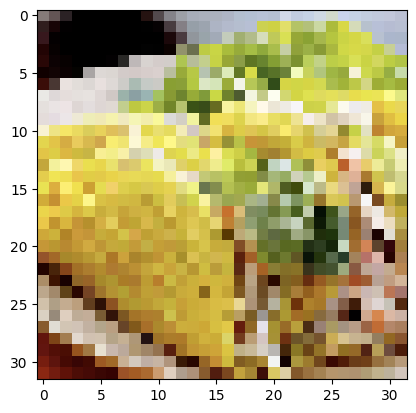

In [ ]:
img=load_img('/content/drive/MyDrive/food/bánh xèo/IMG_8686.PNG', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') /
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Dự đoán: bánh mì


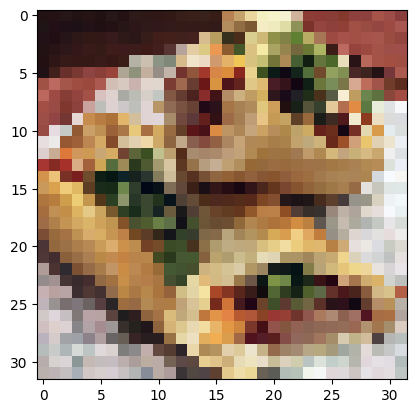

In [ ]:
img=load_img('/content/drive/MyDrive/food/bánh mì/IMG_8697.PNG', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') /
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Dự đoán: bún bò


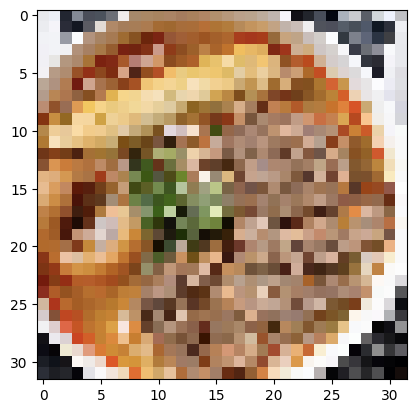

In [ ]:
img=load_img('/content/drive/MyDrive/food/bún bò/IMG_8703.PNG', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') /
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

In [ ]:
model.save('food.h5')